In [ ]:
import numpy as np
from sklearn.cluster import KMeans
# 1D data reshaped to 2D array as required by scikit-learn
X = np.array([[1], [2], [8], [9]])
# Initialize and fit the model
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(X)
print("Cluster centers:", kmeans.cluster_centers_)
print("Labels:", kmeans.labels_)

Cluster centers: [[8.5]
 [1.5]]
Labels: [1 1 0 0]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [ ]:
# Generate a synthetic dataset with 'blobs' that can be clustered
X, y_true = make_blobs(n_samples=300, centers=2, cluster_std=0.80, random_state=0)

print("Shape of the dataset (X):", X.shape)
print("First 5 rows of the dataset:\n", X[:5])

Shape of the dataset (X): (300, 2)
First 5 rows of the dataset:
 [[2.8827859  5.05937092]
 [2.75593373 0.80557769]
 [1.09150494 5.46720613]
 [2.71253609 0.90189778]
 [1.52812461 5.34526431]]


In [ ]:
# Apply K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=0, n_init='auto')
kmeans.fit(X)
labels = kmeans.labels_
centers = kmeans.cluster_centers_

print("Cluster centers:\n", centers)
print("First 5 labels:\n", labels[:5])

Cluster centers:
 [[0.92276934 4.38079448]
 [1.93732751 0.79487415]]
First 5 labels:
 [0 1 0 1 0]


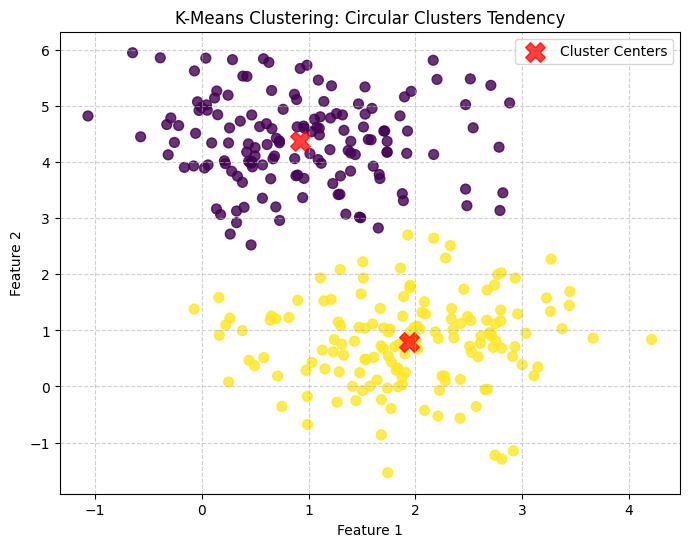

In [ ]:
# Visualize the clusters
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis', alpha=0.8)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Cluster Centers')
plt.title('K-Means Clustering: Circular Clusters Tendency')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# DBScan

In [ ]:
from sklearn.cluster import DBSCAN

# Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.5, min_samples=5) # You might need to tune these parameters for different datasets
dbscan.fit(X)

dbscan_labels = dbscan.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_ = list(dbscan_labels).count(-1)

print(f"Estimated number of clusters: {n_clusters_}")
print(f"Estimated number of noise points: {n_noise_}")
print("First 5 DBSCAN labels:\n", dbscan_labels[:5])

Estimated number of clusters: 2
Estimated number of noise points: 14
First 5 DBSCAN labels:
 [1 0 1 0 1]


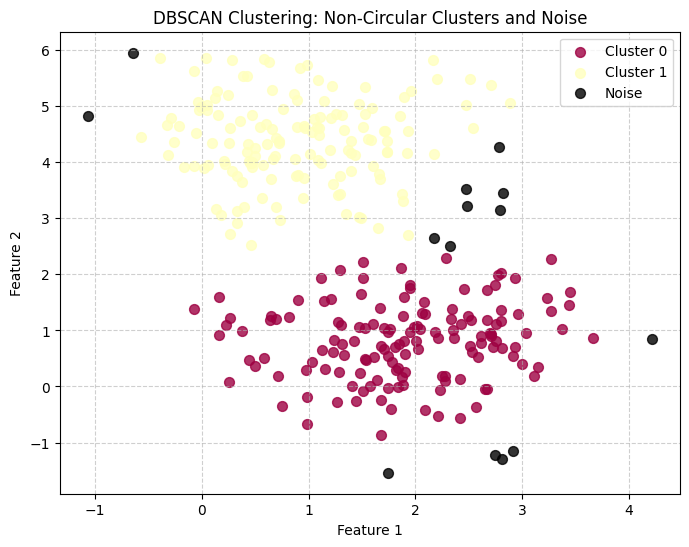

In [ ]:
# Visualize the DBSCAN clusters
plt.figure(figsize=(8, 6))
# Get unique labels
unique_labels = set(dbscan_labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = (dbscan_labels == k)

    xy = X[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], s=50, c=[col], label=f'Cluster {k}' if k != -1 else 'Noise', alpha=0.8)

plt.title('DBSCAN Clustering: Non-Circular Clusters and Noise')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

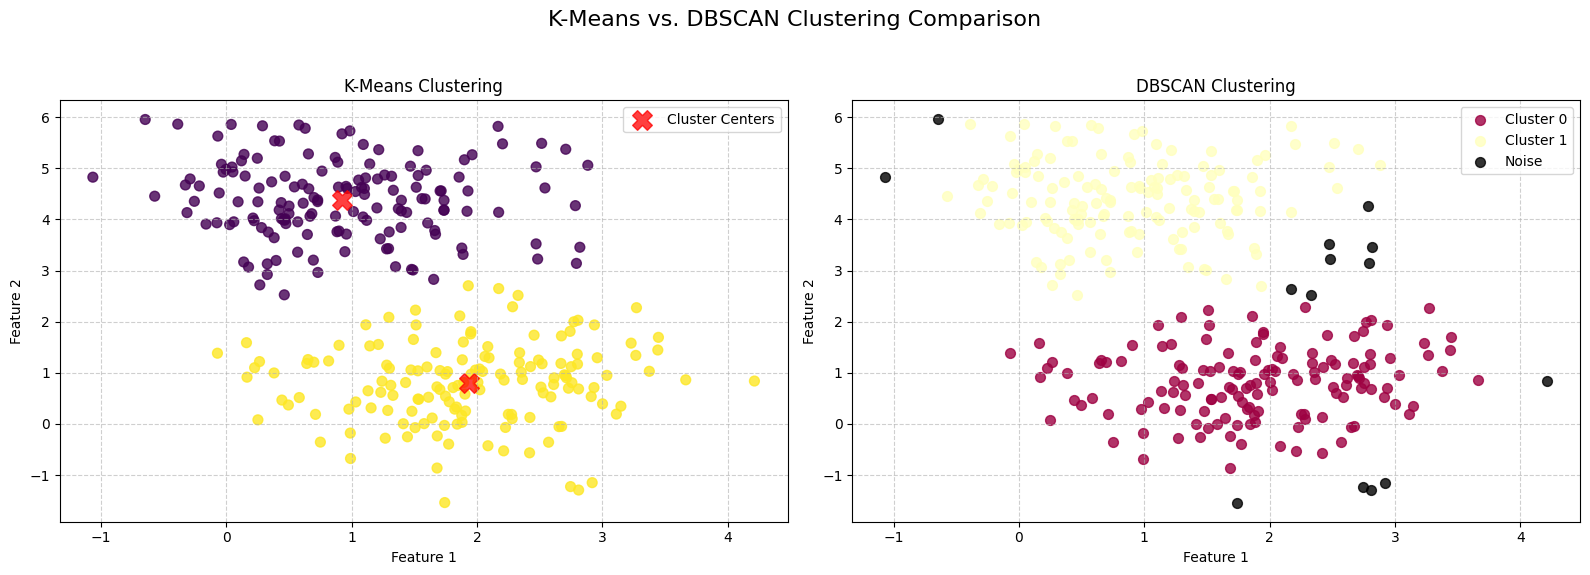

In [ ]:
plt.figure(figsize=(16, 6))

# K-Means Plot (Left Subplot)
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis', alpha=0.8)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Cluster Centers')
plt.title('K-Means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# DBSCAN Plot (Right Subplot)
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
unique_labels_dbscan = set(dbscan_labels)
colors_dbscan = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels_dbscan))]

for k, col in zip(unique_labels_dbscan, colors_dbscan):
    if k == -1:
        col = [0, 0, 0, 1] # Black for noise
    class_member_mask_dbscan = (dbscan_labels == k)
    xy_dbscan = X[class_member_mask_dbscan]
    plt.scatter(xy_dbscan[:, 0], xy_dbscan[:, 1], s=50, c=[col], label=f'Cluster {k}' if k != -1 else 'Noise', alpha=0.8)

plt.title('DBSCAN Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.suptitle('K-Means vs. DBSCAN Clustering Comparison', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

### Side-by-Side Comparison:

Looking at the two plots side-by-side, we can observe the following:

*   **K-Means (Left Plot):** Clearly shows two distinct, circular clusters with their centroids marked. All data points are assigned to a cluster, even those at the fringes or potentially considered noise by other algorithms.

*   **DBSCAN (Right Plot):** Also identified two main clusters. However, it explicitly identified a number of points as 'Noise' (shown in black), which are points that do not belong to any dense region. This demonstrates DBSCAN's robustness to outliers.

For this particular synthetic dataset, both algorithms perform well in identifying the primary cluster structures, but DBSCAN's ability to isolate noise points is evident.

## K-Means vs. DBSCAN: Why DBSCAN Can Be Better

This comparison highlights key differences and scenarios where DBSCAN can outperform K-Means:

1.  **Cluster Shape Flexibility:**
    *   **K-Means:** Assumes clusters are spherical and of similar size. It struggles with arbitrarily shaped clusters, often splitting them or merging adjacent ones.
    *   **DBSCAN:** Can discover clusters of arbitrary shapes (e.g., elongated, crescent-shaped) because it groups together density-connected points rather than fitting to centroids.

2.  **Handling Noise/Outliers:**
    *   **K-Means:** Forces every data point into a cluster, even outliers, which can distort cluster centroids and boundaries. It doesn't explicitly handle noise.
    *   **DBSCAN:** Explicitly identifies noise points (labeled as -1) that do not belong to any cluster, making it robust to outliers. This is crucial in real-world datasets where noise is common.

3.  **Number of Clusters:**
    *   **K-Means:** Requires the number of clusters (`k`) to be specified beforehand. This can be a significant drawback if `k` is unknown.
    *   **DBSCAN:** Automatically determines the number of clusters based on the `eps` (radius) and `min_samples` (density threshold) parameters. It doesn't require prior knowledge of `k`.

### When to use DBSCAN over K-Means:

*   When clusters have irregular or non-spherical shapes.
*   When the dataset contains noise or outliers that should not be grouped into clusters.
*   When the number of clusters is unknown and hard to estimate beforehand.

For the synthetic dataset generated with `make_blobs`, both algorithms perform reasonably well because the data naturally forms somewhat spherical clusters. However, DBSCAN's ability to identify noise (if `eps` and `min_samples` were tuned to consider some points as outliers) and its flexibility with cluster shapes make it a powerful alternative for more complex real-world data.

This plot demonstrates how K-Means partitions the data into roughly circular (or spherical in higher dimensions) regions around its cluster centers. Each color represents a different cluster, and the red 'X' markers indicate the calculated cluster centroids.